In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q condacolab
import condacolab
# Workaround issue with Python 3.12:
# condacolab.install()
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...


In [ ]:
!mamba install -q graph-tool

warning  libmamba [xorg-xorgproto-2024.1-hb9d3cd8_1] The following files were already present in the environment:
    - include/X11/extensions/EVI.h
    - include/X11/extensions/EVIproto.h
    - include/X11/extensions/ag.h
    - include/X11/extensions/agproto.h
    - include/X11/extensions/cup.h
    - include/X11/extensions/cupproto.h
    - include/X11/extensions/dbe.h
    - include/X11/extensions/dbeproto.h
    - include/X11/extensions/dpmsconst.h
    - include/X11/extensions/dpmsproto.h
    - include/X11/extensions/ge.h
    - include/X11/extensions/geproto.h
    - include/X11/extensions/lbx.h
    - include/X11/extensions/lbxproto.h
    - include/X11/extensions/mitmiscconst.h
    - include/X11/extensions/mitmiscproto.h
    - include/X11/extensions/multibufconst.h
    - include/X11/extensions/multibufproto.h
    - include/X11/extensions/secur.h
    - include/X11/extensions/securproto.h
    - include/X11/extensions/shapeconst.h
    - include/X11/extensions/shapeproto.h
    - include/X11

In [ ]:
# Workaround issue with Python 3.12
!mamba install -q scipy

In [ ]:
from graph_tool.all import *

In [ ]:
import networkx as nx
from scipy.io import mmread
import community as community_louvain
import community.community_louvain as community_louvain
import json
from collections import defaultdict
from collections import Counter
import networkx as nx
from networkx.algorithms.swap import connected_double_edge_swap
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import rgb_to_hsv
from matplotlib.colors import rgb_to_hsv, hsv_to_rgb
import numpy as np
!pip install pyvis
import random
from pyvis.network import Network

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.2/616.2 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [pyvis]


# ***Question 2 (40 points). Exploring community detection***

### (a) Download a network dataset from https://networkrepository.com/ with between $1{,}000 < N < 5{,}000$ nodes (select a different dataset from the one you used in Assignment 1). Select a modularity maximization algorithm to detect communities in this graph.

i. Visualize your network, coloring the nodes by community membership.  
ii. Report the modularity of the partition your algorithm found.  
iii. Report the number of communities detected.  
iv. Store your partition as a dictionary, in the form of `{node_id: community_id}`.

In [ ]:
edges_path = "/content/drive/MyDrive/graph-tool/inf-openflights/inf-openflights.edges"

G = nx.read_edgelist(edges_path, comments="%", nodetype=int)

print(f"Graph loaded: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")

Graph loaded: 2,939 nodes, 15,677 edges


In [ ]:
# Louvain community detection
partition = community_louvain.best_partition(G, weight="weight", resolution=1.0, random_state=42)

# Add community as node attribute
nx.set_node_attributes(G, partition, "community")

In [ ]:
# Compute modularity and number of communities
comms = defaultdict(set)
for n, c in partition.items():
    comms[c].add(n)
communities_list = list(comms.values())

modularity = nx.algorithms.community.quality.modularity(G, communities_list, weight="weight")
num_comms = len(communities_list)

print(f"Modularity (Louvain): {modularity:.5f}")
print(f"Number of communities: {num_comms}")

Modularity (Louvain): 0.65399
Number of communities: 34


In [ ]:
# Partition as a dictionary {node_id: community_id}
partition_dict = {int(k): int(v) for k, v in partition.items()}

### (b) Using the same network as in (a), use `{graph-tool}` to create a partition of your network (i.e., run community detection).  Visualize your network again, coloring the nodes by community membership; use the same network visualization layout as in (a).  Store your partition as a dictionary, in the form of `{node_id: community_id}`.

In [ ]:
# Convert the NetworkX graph to a graph-tool graph
node_list = list(G.nodes())
node_to_idx = {node: idx for idx, node in enumerate(node_list)}

# Create the graph-tool graph
g = Graph(directed=False)
g.add_vertex(len(node_list))

# Add edges
for u, v in G.edges():
    g.add_edge(node_to_idx[u], node_to_idx[v])

print(f"Graph-tool graph created: {g.num_vertices():,} vertices and {g.num_edges():,} edges\n")

# Community detection with graph-tool
state = minimize_blockmodel_dl(g)

# Extract community assignments
blocks = state.get_blocks()

# Convert to dictionary {node_id: community_id}
partition_gt = {}
for idx, node in enumerate(node_list):
    partition_gt[node] = int(blocks[idx])

# Compute modularity and number of communities
communities_gt = {}
for node, comm in partition_gt.items():
    if comm not in communities_gt:
        communities_gt[comm] = set()
    communities_gt[comm].add(node)

communities_list_gt = list(communities_gt.values())
modularity_gt = nx.algorithms.community.quality.modularity(G, communities_list_gt)
num_comms_gt = len(communities_list_gt)

print(f"Modularity (graph-tool): {modularity_gt:.5f}")
print(f"Number of communities: {num_comms_gt}")

partition_dict_gt= {int(k): int(v) for k, v in partition_gt.items()}

Graph-tool graph created: 2,939 vertices and 15,677 edges

Modularity (graph-tool): 0.35974
Number of communities: 36


### (c) Create a degree-preserving randomization of your network, and run the two community detection algorithms from above on your randomized graph. Store each partition as a dictionary, in the form of `{node_id: community_id}`.

In [ ]:
# Start from your original graph G (simple graph)
print(f"Original graph: {G.number_of_nodes():,} nodes and {G.number_of_edges():,} edges")


# Degree-preserving randomization with the SAME number of edges
#    - If G is connected → use connected_double_edge_swap (keeps connectivity)
#    - Else → fall back to double_edge_swap (works on disconnected graphs too)
G_random = G.copy()
m = G.number_of_edges()

try:
    # Preferred when the graph is connected
    connected_double_edge_swap(
        G_random,
        nswap=10 * m,   # more swaps → more randomization
        seed=42
    )
except nx.NetworkXError:
    # Fallback for disconnected graphs
    nx.double_edge_swap(
        G_random,
        nswap=10 * m,
        max_tries=100 * m,
        seed=42
    )

assert G_random.number_of_edges() == G.number_of_edges(), "Edge count changed unexpectedly!"
print(f"\nRandomized graph (degree-preserving): {G_random.number_of_nodes():,} nodes and {G_random.number_of_edges():,} edges")


# Louvain on randomized graph
partition_louvain_random = community_louvain.best_partition(
    G_random,
    weight="weight",   # if no 'weight' attr present, it's treated as 1
    resolution=1.0,
    random_state=42
)

# Compute modularity & number of communities
comms_louvain_random = defaultdict(set)
for n, c in partition_louvain_random.items():
    comms_louvain_random[c].add(n)

communities_list_louvain_random = list(comms_louvain_random.values())
modularity_louvain_random = nx.algorithms.community.quality.modularity(
    G_random,
    communities_list_louvain_random,
    weight="weight"
)
num_comms_louvain_random = len(communities_list_louvain_random)

print("\nLouvain on randomized graph:")
print(f"Modularity: {modularity_louvain_random:.5f}")
print(f"Number of communities: {num_comms_louvain_random}")

# Store partition as dictionary
partition_dict_random = {int(k): int(v) for k, v in partition_louvain_random.items()}


# graph-tool on randomized graph
# Convert randomized NetworkX graph to graph-tool
node_list_random = list(G_random.nodes())
node_to_idx_random = {node: idx for idx, node in enumerate(node_list_random)}

g_random = Graph(directed=False)
g_random.add_vertex(len(node_list_random))

for u, v in G_random.edges():
    g_random.add_edge(node_to_idx_random[u], node_to_idx_random[v])

print(f"\nGraph-tool randomized graph created: {g_random.num_vertices():,} vertices and {g_random.num_edges():,} edges")

# Run community detection (SBM/MDL)
# For reproducibility (if supported in your version): state_random = minimize_blockmodel_dl(g_random, random_state=42)
state_random = minimize_blockmodel_dl(g_random)
blocks_random = state_random.get_blocks()

# Convert to dict {node_id: community_id}
partition_gt_random = {}
for idx, node in enumerate(node_list_random):
    partition_gt_random[node] = int(blocks_random[idx])

# Compute modularity & number of communities (using NetworkX modularity for comparison)
communities_gt_random = defaultdict(set)
for node, comm in partition_gt_random.items():
    communities_gt_random[comm].add(node)

communities_list_gt_random = list(communities_gt_random.values())
modularity_gt_random = nx.algorithms.community.quality.modularity(
    G_random,
    communities_list_gt_random
)
num_comms_gt_random = len(communities_list_gt_random)

print("\ngraph-tool on randomized graph:")
print(f"Modularity: {modularity_gt_random:.5f}")
print(f"Number of communities: {num_comms_gt_random}")

# Store partition as dictionary
partition_dict_gt_random = {int(k): int(v) for k, v in partition_gt_random.items()}

Original graph: 2,939 nodes and 15,677 edges

Randomized graph (degree-preserving): 2,939 nodes and 15,677 edges

Louvain on randomized graph:
Modularity: 0.23547
Number of communities: 21

Graph-tool randomized graph created: 2,939 vertices and 15,677 edges

graph-tool on randomized graph:
Modularity: 0.00000
Number of communities: 1


### (d) You should now have four different dictionaries, corresponding to the partitions created in (a-c). Create a figure with four subplots: In each, plot the community size distribution of each partition. Your figure should be publication-ready quality, with well-labeled, consistent axes, log-scaled where relevant, etc.

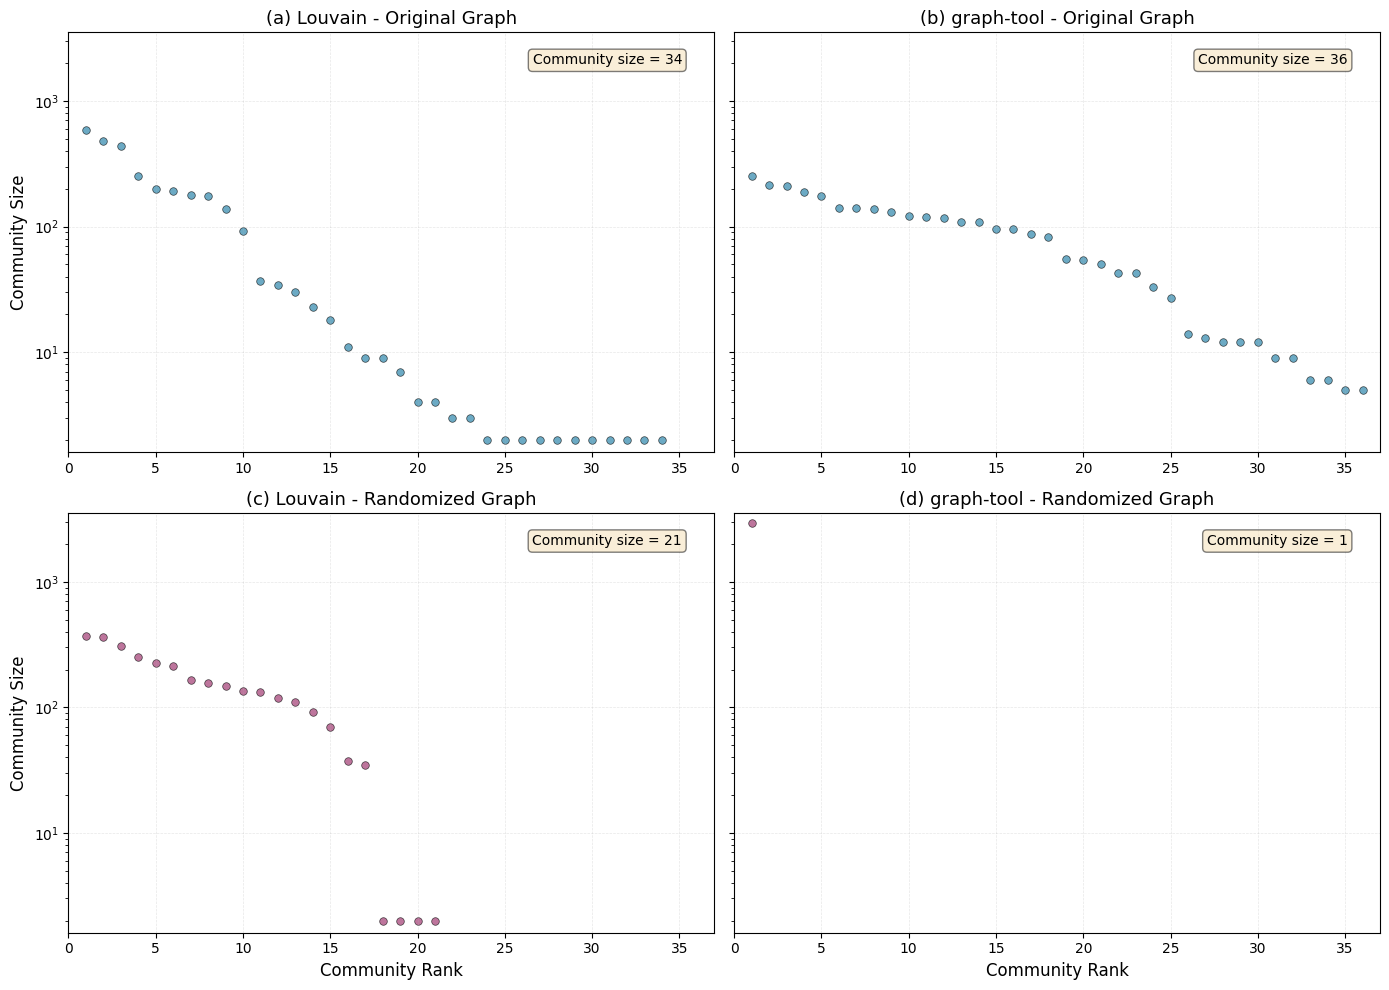

In [ ]:
def get_community_sizes(partition_dict):
    """
    Given a partition dictionary {node_id: community_id},
    return a list of community sizes (sorted in descending order)
    """
    comm_counts = Counter(partition_dict.values())
    return sorted(comm_counts.values(), reverse=True)

# Get community sizes
sizes_louvain_original = get_community_sizes(partition_dict)
sizes_gt_original = get_community_sizes(partition_dict_gt)
sizes_louvain_random = get_community_sizes(partition_dict_random)
sizes_gt_random = get_community_sizes(partition_dict_gt_random)

# Determine axis limits
all_sizes = (
    sizes_louvain_original + sizes_gt_original +
    sizes_louvain_random + sizes_gt_random
)
max_size = max(all_sizes)
min_size = min(all_sizes)
max_rank = max(len(sizes_louvain_original), len(sizes_gt_original),
               len(sizes_louvain_random), len(sizes_gt_random))

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey='row')

marker_size = 30
alpha = 0.7
color_original = '#2E86AB'  # Blue
color_random = '#A23B72'    # Purple

# ---- Subplot (a): Louvain - Original ----
ax = axes[0, 0]
ranks = np.arange(1, len(sizes_louvain_original) + 1)
ax.scatter(ranks, sizes_louvain_original, s=marker_size, alpha=alpha,
           color=color_original, edgecolors='black', linewidth=0.5)
ax.set_title('(a) Louvain - Original Graph', fontsize=13)
ax.set_yscale('log')
ax.set_xlim(0, max_rank + 1)
ax.set_ylim(min_size * 0.8, max_size * 1.2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.text(0.95, 0.95, f'Community size = {len(sizes_louvain_original)}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# ---- Subplot (b): graph-tool - Original ----
ax = axes[0, 1]
ranks = np.arange(1, len(sizes_gt_original) + 1)
ax.scatter(ranks, sizes_gt_original, s=marker_size, alpha=alpha,
           color=color_original, edgecolors='black', linewidth=0.5)
ax.set_title('(b) graph-tool - Original Graph', fontsize=13)
ax.set_yscale('log')
ax.set_xlim(0, max_rank + 1)
ax.set_ylim(min_size * 0.8, max_size * 1.2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.text(0.95, 0.95, f'Community size = {len(sizes_gt_original)}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
# Hide right subplot y-labels
ax.set_ylabel('')

# ---- Subplot (c): Louvain - Randomized ----
ax = axes[1, 0]
ranks = np.arange(1, len(sizes_louvain_random) + 1)
ax.scatter(ranks, sizes_louvain_random, s=marker_size, alpha=alpha,
           color=color_random, edgecolors='black', linewidth=0.5)
ax.set_title('(c) Louvain - Randomized Graph', fontsize=13)
ax.set_yscale('log')
ax.set_xlim(0, max_rank + 1)
ax.set_ylim(min_size * 0.8, max_size * 1.2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.text(0.95, 0.95, f'Community size = {len(sizes_louvain_random)}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Community Rank', fontsize=12)

# ---- Subplot (d): graph-tool - Randomized ----
ax = axes[1, 1]
ranks = np.arange(1, len(sizes_gt_random) + 1)
ax.scatter(ranks, sizes_gt_random, s=marker_size, alpha=alpha,
           color=color_random, edgecolors='black', linewidth=0.5)
ax.set_title('(d) graph-tool - Randomized Graph', fontsize=13)
ax.set_yscale('log')
ax.set_xlim(0, max_rank + 1)
ax.set_ylim(min_size * 0.8, max_size * 1.2)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.text(0.95, 0.95, f'Community size = {len(sizes_gt_random)}',
        transform=ax.transAxes, fontsize=10,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Community Rank', fontsize=12)
ax.set_ylabel('')  # remove duplicate y-label

# ---- Only left column gets shared y-label ----
for i in range(2):
    axes[i, 0].set_ylabel('Community Size', fontsize=12)
for i in range(2):
    axes[i, 1].tick_params(labelleft=False)

plt.tight_layout()
plt.show()

# ***Question 3 (30 points). Benchmarks for community detection.***

### There are many ways to “benchmark” community detection algorithms; one famous approach is known as the [Lancichinetti–Fortunato–Radicchi (LFR) benchmark](https://doi.org/10.1103/PhysRevE.78.046110).

### (b) On page 2 of the article—*in Section II: The Benchmark*—the authors describe the five steps involved in sampling benchmark graphs.

### i. Step 1 is reminiscent of the procedure for creating power-law configuration model networks. Write a function that outputs a power-law degree sequence, $\{k_1, k_2, \dots, k_n\}$, which can be used as input in a configuration model. Your function should take $n$ (network size), $\gamma$ (power-law degree exponent), and $\langle k \rangle$ (average degree) as inputs.

This function generates a degree sequence following a **power-law distribution**.

---

#### 1) Power-law distribution

A power-law degree distribution is defined as:

$$
P(k) \propto k^{-\gamma}
$$

Normalized on the discrete interval $[k_{\min}, k_{\max}]$:

$$
P(k) = \frac{k^{-\gamma}}{\sum_{k = k_{\min}}^{k_{\max}} k^{-\gamma}}
$$

---

#### 2) Maximum degree (finite-size estimate)

The upper cutoff is approximated by:

$$
k_{\max} \approx n^{\frac{1}{\gamma - 1}}
$$

---

#### 3) Sampling degrees

Sample \( n \) independent degrees according to $P(k)$:

$$
k_i \sim P(k), \quad i = 1, 2, \dots, n
$$

---

#### 4) Adjusting the mean degree

After sampling, rescale to match the target average degree \( \langle k \rangle_{\text{target}} \):

$$
k_i' = \text{round}\!\left( k_i \cdot \frac{\langle k \rangle_{\text{target}}}{\langle k \rangle_{\text{sample}}} \right)
$$

---

#### 5) Enforcing constraints

Ensure all degrees are above the minimum:

$$
k_i' \geq k_{\min}
$$

And make the degree sum even (necessary for undirected graphs):

$$
\left( \sum_{i=1}^{n} k_i' \right) \bmod 2 = 0
$$

---

#### 6) Outputs

- **`degrees`** — the generated degree sequence $(k_1', k_2', \dots, k_n')$  
- **`k_values`** — the range of degrees $\{ k_{\min}, \dots, k_{\max} \}$  
- **`p`** — the normalized probability distribution $P(k)$

---

In summary, this algorithm produces a **synthetic degree sequence** consistent with a power-law distribution, preserving a desired average degree and ensuring the resulting network is suitable for use in the **configuration model**.

In [ ]:
def generate_powerlaw_degree_sequence(n, gamma, k_avg, k_min=1):
    """
    Generate a power-law degree sequence usable in a configuration model.
    """
    #Approximate maximum degree
    k_max = int(n ** (1 / (gamma - 1)))
    k_values = np.arange(k_min, k_max + 1)

    #Power-law probabilities
    p = k_values ** (-gamma)
    p /= p.sum()

    #Sample degrees
    degrees = np.random.choice(k_values, size=n, p=p)

    #Adjust mean degree
    current_avg = degrees.mean()
    scale_factor = k_avg / current_avg
    degrees = np.round(degrees * scale_factor).astype(int)
    degrees[degrees < k_min] = k_min

    #Ensure even degree sum
    if degrees.sum() % 2 != 0:
        degrees[np.random.randint(0, n)] += 1

    return degrees, k_values, p

This code creates a grid of log–log plots comparing the *empirical* and *theoretical* degree distributions generated by the `generate_powerlaw_degree_sequence` function for different combinations of parameters $\gamma$ (the power-law exponent) and $ \langle k \rangle $ (the target average degree).

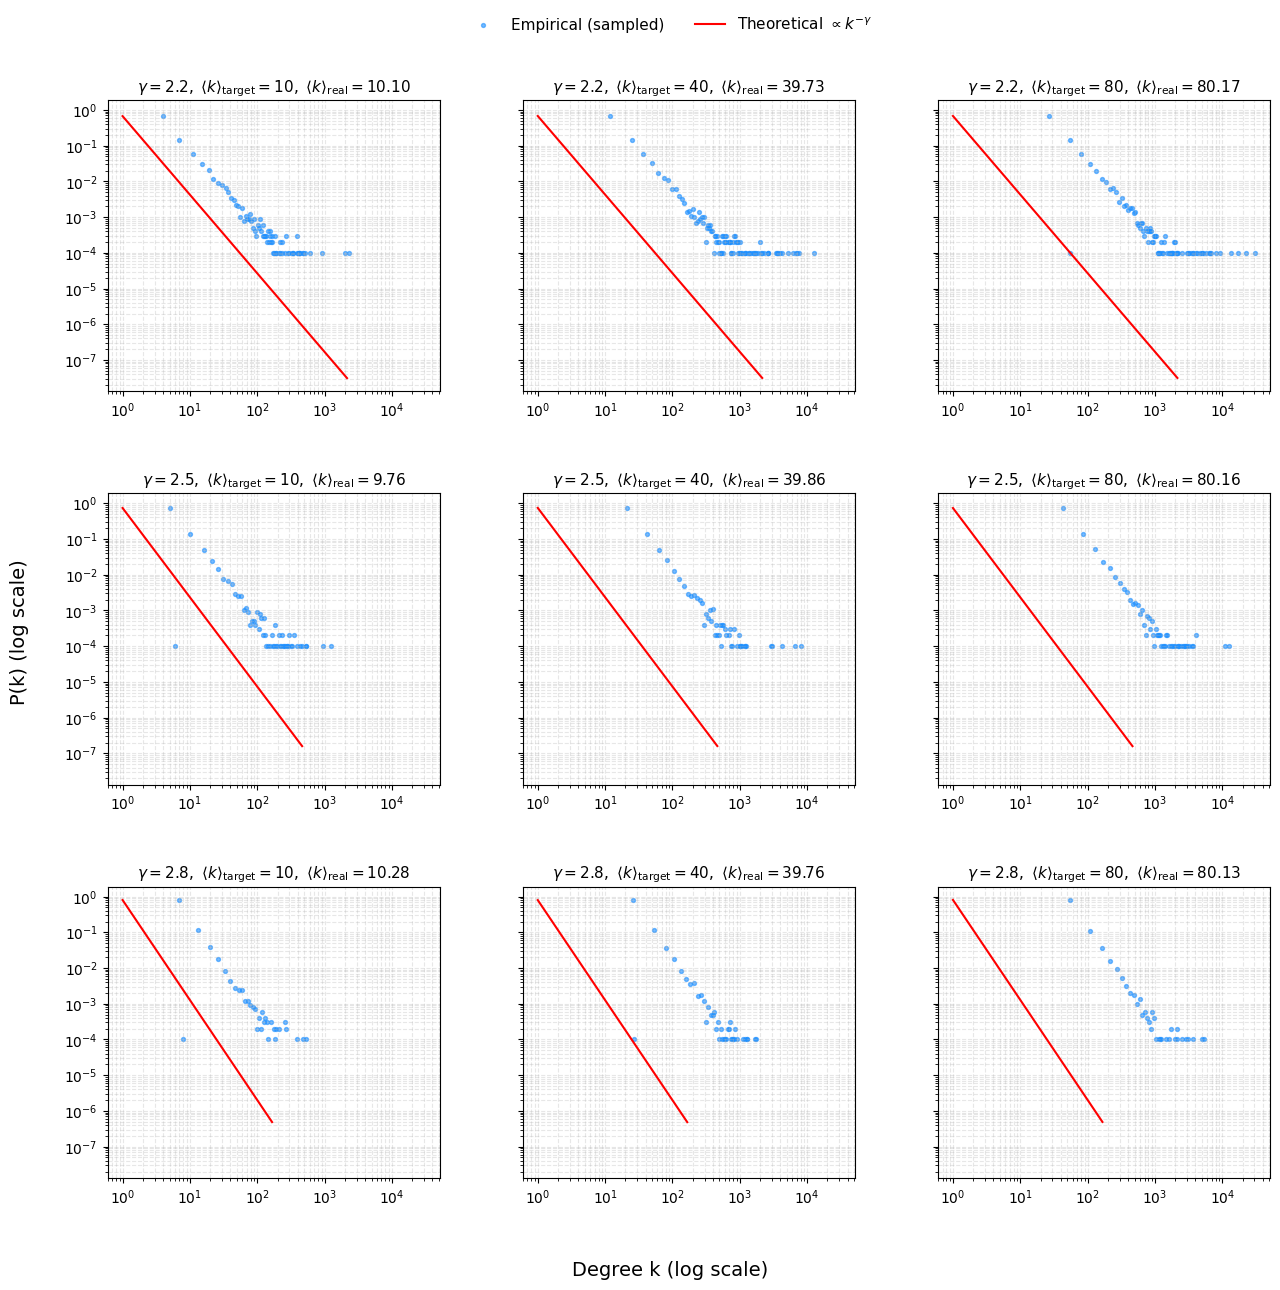

In [ ]:
gammas = [2.2, 2.5, 2.8]   # Power-law exponents
k_avgs = [10, 40, 80]      # Target average degrees
n = 10000                 # Number of nodes (example)

# Create the figure grid
fig, axes = plt.subplots(3, 3, figsize=(15, 14), sharex=True, sharey=True)
plt.subplots_adjust(hspace=0.35, wspace=0.25)

# Create handles for the global legend
handles_global = []
labels_global = []


for i, gamma in enumerate(gammas):
    for j, k_avg in enumerate(k_avgs):
        ax = axes[i, j]

        # Generate the degree sequence
        degrees, k_values, p_theoretical = generate_powerlaw_degree_sequence(n, gamma, k_avg)
        k_real = degrees.mean()

        # Empirical distribution
        unique_k, counts = np.unique(degrees, return_counts=True)
        p_empirical = counts / counts.sum()

        # Normalize the theoretical distribution
        p_theoretical = p_theoretical / p_theoretical.sum()
        p_theoretical_scaled = p_theoretical * (p_empirical.max() / p_theoretical.max())

        # Plot (store handles only during the first iteration)
        s = ax.scatter(unique_k, p_empirical, color="dodgerblue", s=8, alpha=0.6, label="Empirical (sampled)")
        l, = ax.plot(k_values, p_theoretical_scaled, color="red", linewidth=1.5, label=r"Theoretical $\propto k^{-\gamma}$")
        if i == 0 and j == 0:
            handles_global = [s, l]
            labels_global = ["Empirical (sampled)", r"Theoretical $\propto k^{-\gamma}$"]

        # Log–log scale and grid
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.grid(True, which="both", linestyle="--", alpha=0.3)

        # Title with formatted parameters
        ax.set_title(
            rf"$\gamma = {gamma}, \ \langle k\rangle_{{\mathrm{{target}}}} = {k_avg}, \ \langle k\rangle_{{\mathrm{{real}}}} = {k_real:.2f}$",
            fontsize=11
        )


for ax_row in axes:
    for ax in ax_row:
        ax.tick_params(labelbottom=True, bottom=True)


fig.text(0.5, 0.04, "Degree k (log scale)", ha='center', fontsize=14)
fig.text(0.06, 0.5, "P(k) (log scale)", va='center', rotation='vertical', fontsize=14)


fig.legend(
    handles_global,
    labels_global,
    loc="upper center",
    fontsize=11,
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.95)
)

plt.show()

### ii. Step 2 introduces a mixing parameter, $ \mu $, that is used to assign a fraction of a node’s total degree, $ k_i $, to be *internal* community edges (i.e., connecting to nodes with the same community label as node $ i $), such that:

$$
k_i^{in} = k_i (1 - \mu)
$$

### With probability $ \mu $, therefore, the remaining edges of $ i $ are connected to nodes *external* to the community:

$$
k_i^{out} = k_i \mu = k_i - k_i^{in}
$$

### Write a function that implements this step.


In [ ]:
def assign_internal_external_degrees(degrees, mu):
    """
    Step 2 of the benchmark: assign internal/external degrees per node
    based on the mixing parameter μ.

    Parameters
    ----------
    degrees : np.ndarray
        Total degree sequence for all nodes (from Step 1).
    mu : float
        Mixing parameter (fraction of edges that go outside the community).
        0 <= mu <= 1

    Returns
    -------
    k_in : np.ndarray
        Internal degrees (edges within the same community)
    k_out : np.ndarray
        External degrees (edges to other communities)
    """
    if not 0 <= mu <= 1:
        raise ValueError("μ must be between 0 and 1.")

    # Internal edges: fraction (1 - μ) of total degree
    k_in = np.round(degrees * (1 - mu)).astype(int)

    # External edges: complement fraction μ
    k_out = degrees - k_in

    # Correction: ensure total sum consistency
    diff = degrees.sum() - (k_in + k_out).sum()
    if diff != 0:
        # adjust randomly by distributing +/-1 differences
        for _ in range(abs(diff)):
            i = np.random.randint(0, len(degrees))
            if diff > 0:
                k_out[i] += 1
            else:
                k_out[i] = max(0, k_out[i] - 1)

    return k_in, k_out

In [ ]:
# Step 1: degree sequence
degrees, _, _ = generate_powerlaw_degree_sequence(n=10000, gamma=2.5, k_avg=8)

# Step 2: assign mixing parameter μ
mu = 0.3
k_in, k_out = assign_internal_external_degrees(degrees, mu)

# Show 10 random examples
print("=== Example nodes (first 10) ===")
for i in range(10):
    print(f"Node {i:>2}: k = {degrees[i]:>3}, k_in = {k_in[i]:>3}, k_out = {k_out[i]:>3}")

# Check average internal fraction
avg_internal_frac = (k_in / degrees).mean()
print("\n=== Summary ===")
print(f"Average internal fraction: {avg_internal_frac:.2f} ≈ 1 - μ = {1 - mu}")
print(f"Average external fraction: {(k_out / degrees).mean():.2f} ≈ μ = {mu}")

=== Example nodes (first 10) ===
Node  0: k =   4, k_in =   3, k_out =   1
Node  1: k =   4, k_in =   3, k_out =   1
Node  2: k =   8, k_in =   6, k_out =   2
Node  3: k =   4, k_in =   3, k_out =   1
Node  4: k =   8, k_in =   6, k_out =   2
Node  5: k =   8, k_in =   6, k_out =   2
Node  6: k =   8, k_in =   6, k_out =   2
Node  7: k =   4, k_in =   3, k_out =   1
Node  8: k =   4, k_in =   3, k_out =   1
Node  9: k =   4, k_in =   3, k_out =   1

=== Summary ===
Average internal fraction: 0.74 ≈ 1 - μ = 0.7
Average external fraction: 0.26 ≈ μ = 0.3


### (c) `networkx` has a built-in function, `nx.LFR benchmark graph()`, that can generate these benchmark graphs. Many users of this algorithm report its inconsistency in convergence. Explore this function’s usage for yourself: Are there certain parameter combinations that make the algorithm converge more/less successfully? Based on your reading of the original LFR paper, and your experiments above, briefly describe why you think this function has difficulty converging.

In [ ]:
from networkx.generators.community import LFR_benchmark_graph

In [ ]:
def try_lfr(label, **kwargs):
    try:
        G = LFR_benchmark_graph(**kwargs)
        print(f"[OK ] {label:30s} | n={G.number_of_nodes():>4}, m={G.number_of_edges():>6}")
    except Exception as e:
        print(f"[FAIL] {label:30s} | {e.__class__.__name__}: {e}")

# Common settings you can reuse
BASE = dict(
    n=800,
    tau1=2.5,           # degree exponent (power law)
    tau2=1.5,           # community-size exponent (power law)
    max_degree=80,
    min_community=12,
    max_community=200,
    seed=1,
    max_iters=5000      # iteration budget inside the generator
)

print("\n=== A) NON-CONVERGENCE (hard cases) ===")

# A1) Very high mixing with low degrees → not enough intra-community stubs
A1 = dict(BASE, mu=0.85, min_degree=3, max_degree=12, min_community=10, max_community=60, seed=2)
try_lfr("A1 high mu + low deg", **A1)

# A2) Heavy-tailed sizes + relatively small communities → assignment struggles
A2 = dict(BASE, tau1=2.2, tau2=1.1, mu=0.55, min_degree=6, max_degree=40,
          min_community=8, max_community=50, seed=3)
try_lfr("A2 heavy tails small comm", **A2)

# A3) Near strong-communities boundary, small degrees
A3 = dict(BASE, mu=0.6, min_degree=4, max_degree=20, min_community=10, max_community=60, seed=4)
try_lfr("A3 mu~0.6 + small deg", **A3)

# A4) High average degree with tight communities (use average_degree, NOT min_degree)
A4 = dict(BASE, mu=0.4, tau1=2.3, tau2=1.3,
          average_degree=40,           # IMPORTANT: don't pass min_degree here
          max_degree=60,
          min_community=10, max_community=40, seed=5)
# Ensure we don't pass min_degree when using average_degree
A4.pop("min_degree", None)
try_lfr("A4 high avg_deg tight comm", **A4)

# A5) Large n and heavy tails increase difficulty
A5 = dict(BASE, n=3000, mu=0.5, tau1=2.1, tau2=1.2, min_degree=6, max_degree=70,
          min_community=8, max_community=80, seed=6)
try_lfr("A5 larger n heavy tails", **A5)

# A6) Force non-convergence by slashing iteration budget (artificial stress)
A6 = dict(BASE, mu=0.5, min_degree=5, max_degree=40, min_community=10, max_community=50,
          max_iters=50, seed=7)  # intentionally tiny
try_lfr("A6 tiny max_iters stress", **A6)

# A7) Very heavy tails: many high-degree nodes vs modest communities
A7 = dict(BASE, tau1=2.05, tau2=1.05, mu=0.45, min_degree=5, max_degree=80,
          min_community=10, max_community=70, seed=8)
try_lfr("A7 very heavy tails", **A7)

# A8) Moderate mu + conflicting ranges make assignments grind
A8 = dict(BASE, mu=0.55, min_degree=7, max_degree=50,
          min_community=8, max_community=45, tau1=2.2, tau2=1.2, seed=9)
try_lfr("A8 tight comm vs deg", **A8)


print("\n=== B) INFEASIBLE (immediate logical failure) ===")

# B1) min_community < min_degree (paper’s constraint violation) → immediate fail
B1 = dict(BASE, mu=0.3, min_degree=20, max_degree=50, min_community=5, max_community=120, seed=10)
try_lfr("B1 min_comm < min_deg", **B1)

# B2) max_community < max_degree → immediate fail
B2 = dict(BASE, mu=0.3, min_degree=10, max_degree=60, min_community=12, max_community=30, seed=11)
try_lfr("B2 max_comm < max_deg", **B2)

# B3) Illegal: passing both min_degree and average_degree → API error (not convergence)
B3 = dict(BASE, mu=0.3, min_degree=10, average_degree=20, seed=12)
try_lfr("B3 min_deg & avg_deg together", **B3)


=== A) NON-CONVERGENCE (hard cases) ===
[OK ] A1 high mu + low deg           | n= 800, m=  2339
[OK ] A2 heavy tails small comm      | n= 800, m=  6188
[OK ] A3 mu~0.6 + small deg          | n= 800, m=  3523
[FAIL] A4 high avg_deg tight comm     | ExceededMaxIterations: Could not match average_degree
[OK ] A5 larger n heavy tails        | n=3000, m= 28279
[OK ] A6 tiny max_iters stress       | n= 800, m=  4885
[OK ] A7 very heavy tails            | n= 800, m=  6788
[OK ] A8 tight comm vs deg           | n= 800, m=  7435

=== B) INFEASIBLE (immediate logical failure) ===
[FAIL] B1 min_comm < min_deg          | ExceededMaxIterations: Could not assign communities; try increasing min_community
[FAIL] B2 max_comm < max_deg          | ExceededMaxIterations: Could not assign communities; try increasing min_community
[FAIL] B3 min_deg & avg_deg together  | NetworkXError: Must assign exactly one of min_degree and average_degree


In [ ]:
def run_case(label, **kwargs):
    try:
        G = LFR_benchmark_graph(**kwargs)
        # If it succeeded, return None (we only want ExceededMaxIterations)
        return None
    except Exception as e:
        if e.__class__.__name__ == "ExceededMaxIterations":
            return (label, e.__class__.__name__, str(e))
        # Ignore other errors (API misuse or infeasible) — we want *non-convergence* only
        return None

def print_hit(hit):
    label, etype, msg = hit
    print(f"[HIT] {label:34s} | {etype}: {msg}")

hits = []

# -------------------------------
# Family 1: High average_degree + tight community caps
# -------------------------------
base1 = dict(
    n=800, tau1=2.3, tau2=1.3, mu=0.45,
    # Use ONLY average_degree (no min_degree)
    average_degree=36,
    max_degree=60,              # must be <= max_community
    min_community=10,
    max_community=60,           # tight cap at max_degree boundary
    max_iters=5000,
)
for seed in range(1, 7):
    params = dict(base1, seed=seed)
    hit = run_case(f"F1 seed={seed} avg_deg=36 caps=10..60 mu=0.45", **params)
    if hit: hits.append(hit)

# -------------------------------
# Family 2: Push mu high with small degrees via low average_degree, but keep caps tight
# -------------------------------
base2 = dict(
    n=800, tau1=2.4, tau2=1.4, mu=0.75,
    average_degree=6,          # low degrees + high mixing → internal targets hard
    max_degree=12,
    min_community=6,
    max_community=12,          # tight (equal to max_degree)
    max_iters=5000,
)
for seed in range(1, 7):
    params = dict(base2, seed=seed)
    hit = run_case(f"F2 seed={seed} mu=0.75 low_deg caps=6..12", **params)
    if hit: hits.append(hit)

# -------------------------------
# Family 3: Very heavy tails + tight community caps + moderate/high average_degree
# -------------------------------
base3 = dict(
    n=1000, tau1=2.05, tau2=1.05, mu=0.55,
    average_degree=24,
    max_degree=50,
    min_community=8,
    max_community=50,          # = max_degree (tight)
    max_iters=5000,
)
for seed in range(1, 7):
    params = dict(base3, seed=seed)
    hit = run_case(f"F3 seed={seed} heavy_tails avg=24 caps=8..50 mu=0.55", **params)
    if hit: hits.append(hit)

# -------------------------------
# Family 4: Larger n + moderately hard settings (often exposes iteration limits)
# -------------------------------
base4 = dict(
    n=3500, tau1=2.2, tau2=1.2, mu=0.58,
    average_degree=28,
    max_degree=70,
    min_community=10,
    max_community=70,          # tight
    max_iters=4000,            # slightly reduced vs default
)
for seed in range(1, 6):
    params = dict(base4, seed=seed)
    hit = run_case(f"F4 seed={seed} n=3500 avg=28 caps=10..70 mu=0.58", **params)
    if hit: hits.append(hit)

# -------------------------------
# Family 5: Explicit iteration-budget stress on already hard settings
# -------------------------------
base5 = dict(
    n=1000, tau1=2.2, tau2=1.2, mu=0.6,
    average_degree=22,
    max_degree=45,
    min_community=8,
    max_community=45,          # tight
    max_iters=50,              # tiny on purpose
)
for seed in range(1, 11):
    params = dict(base5, seed=seed)
    hit = run_case(f"F5 seed={seed} tiny_iters=50 avg=22 caps=8..45 mu=0.6", **params)
    if hit: hits.append(hit)

# -------------------------------
# Family 6: Grid sweep over mu and community “tightness”
# -------------------------------
def tight_case(n=900, tau1=2.25, tau2=1.2, mu=0.5, avg=22, max_deg=50, tightness=1.0, max_iters=3000, seed=1):
    # tightness ∈ (0.8..1.0]; 1.0 means max_community == max_degree (very tight)
    max_comm = int(round(max_deg * tightness))
    max_comm = max(max_comm, max_deg)  # ensure >= max_degree
    return dict(
        n=n, tau1=tau1, tau2=tau2, mu=mu,
        average_degree=avg,
        max_degree=max_deg,
        min_community=max(6, int(0.2*max_comm)),  # keep reasonable lower bound
        max_community=max_comm,
        max_iters=max_iters, seed=seed
    )

for mu in [0.55, 0.6, 0.65]:
    for tight in [1.0, 0.95, 0.9]:
        for seed in [1, 2, 3]:
            params = tight_case(mu=mu, tightness=tight, seed=seed)
            label = f"F6 mu={mu:.2f} tight={tight:.2f} seed={seed}"
            hit = run_case(label, **params)
            if hit: hits.append(hit)

# -------------------------------
# Print results
# -------------------------------
if hits:
    print("\n=== ExceededMaxIterations hits ===")
    for h in hits:
        print_hit(h)
    print(f"\nTotal ExceededMaxIterations: {len(hits)}")
else:
    print("No ExceededMaxIterations hits. To force more failures, try:")
    print("- Increase mu (e.g., 0.7–0.85),")
    print("- Increase average_degree while keeping max_community == max_degree,")
    print("- Make tau1 -> 2.0+ and tau2 -> 1.0+ (heavier tails),")
    print("- Reduce max_iters further (e.g., 20–50).")


=== ExceededMaxIterations hits ===
[HIT] F1 seed=1 avg_deg=36 caps=10..60 mu=0.45 | ExceededMaxIterations: Could not match average_degree
[HIT] F1 seed=2 avg_deg=36 caps=10..60 mu=0.45 | ExceededMaxIterations: Could not match average_degree
[HIT] F1 seed=3 avg_deg=36 caps=10..60 mu=0.45 | ExceededMaxIterations: Could not match average_degree
[HIT] F1 seed=4 avg_deg=36 caps=10..60 mu=0.45 | ExceededMaxIterations: Could not match average_degree
[HIT] F1 seed=5 avg_deg=36 caps=10..60 mu=0.45 | ExceededMaxIterations: Could not match average_degree
[HIT] F1 seed=6 avg_deg=36 caps=10..60 mu=0.45 | ExceededMaxIterations: Could not match average_degree
[HIT] F3 seed=1 heavy_tails avg=24 caps=8..50 mu=0.55 | ExceededMaxIterations: Could not match average_degree
[HIT] F3 seed=2 heavy_tails avg=24 caps=8..50 mu=0.55 | ExceededMaxIterations: Could not match average_degree
[HIT] F3 seed=3 heavy_tails avg=24 caps=8..50 mu=0.55 | ExceededMaxIterations: Could not match average_degree
[HIT] F3 seed=4 